# qualitative_reorganized

Faithful recreation (from the recovered PDF) of the **qualitative** §4.1 analysis on the Flowity
test set: per-image mIoU + significance, depth/distance, confusion & size, boundary/centerline,
error composition, majority vote, FP on clean images and the final qualitative panels.

**Inputs:** Flowity data `data/2026-01-19-defect_dataset/{images,labels_basic_defects_relabel,splits/test.txt}`
and per-model raw index masks at `experiments/<model>/outputx5/seed_<S>/test/raw_masks/` (regenerate
with `run_flowity_test.sh`). Full narrative is in `source_pdf/qualitative_reorganized.pdf`.
Run inside the container with cwd=/app so `BASE_APP_DIR` resolves to `/app`.

## 0. Setup & helpers

In [1]:
# --- stdlib ---
import math
import random
import collections
from pathlib import Path
from functools import lru_cache
from itertools import combinations

import cv2
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon, friedmanchisquare, binomtest
from scipy.ndimage import binary_dilation, label as cc_label
from skimage.morphology import skeletonize
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
import seaborn as sns
from itables import init_notebook_mode
from IPython.display import display, display_html

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
init_notebook_mode(True)

current_dir = Path.cwd()
if "app" in current_dir.parts:
    idx = current_dir.parts.index("app")
    BASE_APP_DIR = Path(*current_dir.parts[:idx + 1])
else:
    BASE_APP_DIR = Path("/")
print(f" Notebook cwd: {current_dir}")
print(f" Project root: '{BASE_APP_DIR.resolve()}'")

 Notebook cwd: /app/notebooks/results_analysis
 Project root: '/app'


In [2]:
PATHS = {
    "Original": BASE_APP_DIR / "data/2026-01-19-defect_dataset/images",
    "Ground_Truth": BASE_APP_DIR / "data/2026-01-19-defect_dataset/labels_basic_defects_relabel",
    "Swin": BASE_APP_DIR / "experiments/swin-T-512x512/outputx5/seed_91/test/raw_masks",
    "BeiT2": BASE_APP_DIR / "experiments/BeiT2-T/outputx5/seed_42/test/raw_masks",
    "HRNet": BASE_APP_DIR / "experiments/HRNet-T-512x512/outputx5/seed_1337/test/raw_masks",
    "FlashInterImage": BASE_APP_DIR / "experiments/flashInternImage-T-512x512/outputx5/seed_777/test/raw_masks",
    "InterImage": BASE_APP_DIR / "experiments/InterImage-T-512x512/outputx5/seed_91/test/raw_masks",
}
split_file_path = BASE_APP_DIR / "data/2026-01-19-defect_dataset/splits/test.txt"

CLASS_NAMES = ["bg", "cracks", "cracks_alligator", "cracks_severe", "edge_cracks",
               "fretting", "pothole", "manhole", "pole_shadow"]
model_keys = [k for k in PATHS.keys() if k not in ["Ground_Truth", "Original"]]

# Official palette from config.py (index 0 = bg). Keeps figures consistent.
PALETTE = [[0, 0, 0], [250, 50, 83], [36, 179, 83], [102, 204, 255],
           [255, 165, 0], [128, 128, 128], [255, 255, 0], [0, 255, 255], [255, 0, 255]]

RUN_HEAVY_VISUALS = False   # True = render the full galleries below
N_SHOW = 8

In [3]:
CMAP = ListedColormap(np.array(PALETTE) / 255)
NORM = BoundaryNorm(np.arange(-0.5, len(CLASS_NAMES) + 0.5), CMAP.N)

@lru_cache(maxsize=None)
def _imread_gray(path_str):
    """Decode a label PNG once and cache it (None if missing)."""
    return cv2.imread(path_str, cv2.IMREAD_GRAYSCALE)

def _load_original(img_id):
    p = PATHS["Original"] / f"{img_id}.jpg"
    return cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB) if p.exists() else None

@lru_cache(maxsize=None)
def load_aligned_masks(img_id, model_key):
    """GT + prediction as label maps; pred forced onto the GT grid (nearest)."""
    gt_path = PATHS["Ground_Truth"] / f"{img_id}.png"
    pred_path = PATHS[model_key] / f"{img_id}.png"
    if not gt_path.exists() or not pred_path.exists():
        return None, None
    gt = _imread_gray(str(gt_path))
    pred = _imread_gray(str(pred_path))
    if gt is None or pred is None:
        return None, None
    if pred.shape != gt.shape:
        pred = cv2.resize(pred, (gt.shape[1], gt.shape[0]), interpolation=cv2.INTER_NEAREST)
    return gt, pred

# --- Error map ---
def build_error_map(gt, pred):
    gt_def, pred_def = gt > 0, pred > 0
    err = np.zeros((*gt.shape, 3), dtype=np.uint8)
    err[gt_def & pred_def] = (0, 200, 0)     # TP
    err[pred_def & ~gt_def] = (220, 30, 30)  # FP
    err[gt_def & ~pred_def] = (30, 70, 220)  # FN
    return err

ERR_LEGEND = [
    mpatches.Patch(color=(0, 200/255, 0), label='TP (GT & Pred)'),
    mpatches.Patch(color=(220/255, 30/255, 30/255), label='FP (Pred - GT)'),
    mpatches.Patch(color=(30/255, 70/255, 220/255), label='FN (GT - Pred)'),
]

def overlay_gt(img_id, alpha=0.5):
    orig = _load_original(img_id)
    gt = cv2.imread(str(PATHS["Ground_Truth"] / f"{img_id}.png"), cv2.IMREAD_GRAYSCALE)
    if orig is None or gt is None:
        return orig
    if gt.shape != orig.shape[:2]:
        gt = cv2.resize(gt, (orig.shape[1], orig.shape[0]), interpolation=cv2.INTER_NEAREST)
    color_gt = (CMAP(NORM(gt))[..., :3] * 255).astype(np.uint8)
    out, m = orig.copy(), gt > 0
    out[m] = (alpha * color_gt[m] + (1 - alpha) * orig[m]).astype(np.uint8)
    return out

def show_single_model(img_id, model_key, alpha=0.5):
    gt, pred = load_aligned_masks(img_id, model_key)
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ov = overlay_gt(img_id, alpha)
    if ov is not None: ax[0].imshow(ov)
    ax[0].set_title("Original + GT")
    if gt is not None:
        ax[1].imshow(pred, cmap=CMAP, norm=NORM); ax[1].set_title(model_key)
        ax[2].imshow(build_error_map(gt, pred)); ax[2].set_title("TP / FP / FN")
        fig.legend(handles=ERR_LEGEND, loc='lower center', ncol=3, frameon=False, fontsize=10)
    else:
        for a in (ax[1], ax[2]):
            a.text(0.5, 0.5, "Not Found", ha='center', va='center', color='crimson', fontweight='bold')
    for a in ax: a.axis('off')
    plt.tight_layout(); plt.show()

def show_all_models(img_id, alpha=0.5):
    cols = ["Overlay"] + model_keys
    fig, ax = plt.subplots(1, len(cols), figsize=(4 * len(cols), 5))
    ov = overlay_gt(img_id, alpha)
    if ov is not None: ax[0].imshow(ov)
    ax[0].set_title("Original + GT", fontweight='bold')
    for i, mk in enumerate(model_keys, start=1):
        _, pred = load_aligned_masks(img_id, mk)
        if pred is not None:
            ax[i].imshow(pred, cmap=CMAP, norm=NORM)
        else:
            ax[i].text(0.5, 0.5, "Not Found", ha='center', va='center', color='crimson', fontweight='bold')
        ax[i].set_title(mk, fontweight='bold')
    for a in ax: a.axis('off')
    plt.tight_layout(); plt.show()

def plot_error_maps(img_id, alpha=0.5):
    cols = ["Overlay"] + model_keys
    fig, ax = plt.subplots(1, len(cols), figsize=(4 * len(cols), 5))
    ov = overlay_gt(img_id, alpha)
    if ov is not None: ax[0].imshow(ov)
    ax[0].set_title("Original + GT", fontweight='bold')
    for i, mk in enumerate(model_keys, start=1):
        gt, pred = load_aligned_masks(img_id, mk)
        if gt is not None:
            ax[i].imshow(build_error_map(gt, pred))
        else:
            ax[i].text(0.5, 0.5, "Not Found", ha='center', va='center', color='crimson', fontweight='bold')
        ax[i].set_title(mk, fontweight='bold')
    for a in ax: a.axis('off')
    fig.legend(handles=ERR_LEGEND, loc='lower center', ncol=3, frameon=False,
               fontsize=11, bbox_to_anchor=(0.5, -0.04))
    plt.tight_layout(); plt.show()

def side_by_side(*dfs, titles=(), font_size=10, pad="2px 6px", gap=22):
    """Render several DataFrames in a single row (compact font, no wrap)."""
    boxes = ""
    for i, df in enumerate(dfs):
        t = titles[i] if i < len(titles) else ""
        sty = df.style.set_table_styles([
            {"selector": "th, td", "props": [("font-size", f"{font_size}px"),
             ("padding", pad), ("text-align", "center")]}])
        boxes += (f'<div style="display:inline-block;vertical-align:top;margin-right:{gap}px">'
                  f'<div style="text-align:center;font-weight:bold;font-size:{font_size+2}px;margin:4px">{t}</div>'
                  f'{sty.to_html()}</div>')
    display_html(f'<div style="display:flex;flex-wrap:nowrap;overflow-x:auto;align-items:flex-start">{boxes}</div>', raw=True)

# helper reconstructed from usage (not fully shown in the source PDF):
# 3 equal horizontal bands from the horizon down: far (top) / mid / near (bottom).
def zone_masks(h, w, horizon_frac=0.40):
    cy = int(horizon_frac * h)
    edges = np.linspace(cy, h, 4).astype(int)
    out = []
    for i, name in enumerate(["far", "mid", "near"]):
        top, bot = edges[i], edges[i + 1]
        m = np.zeros((h, w), bool); m[top:bot, :] = True
        out.append((name, m))
    return out

In [4]:
all_models_rows = []
with open(split_file_path, "r") as f:
    image_ids = [line.strip() for line in f if line.strip()]

for model_key in model_keys:
    for img_id in image_ids:
        gt_mask, pred_mask = load_aligned_masks(img_id, model_key)
        if gt_mask is None:
            continue
        ious_with_bg, ious_without_bg, present_defects = [], [], []
        for c_idx in range(len(CLASS_NAMES)):
            if c_idx != 0 and np.any(gt_mask == c_idx):
                present_defects.append(CLASS_NAMES[c_idx])
            intersection = np.logical_and(gt_mask == c_idx, pred_mask == c_idx).sum()
            union = np.logical_or(gt_mask == c_idx, pred_mask == c_idx).sum()
            if union > 0:
                iou = intersection / union
                ious_with_bg.append(iou)
                if c_idx != 0:
                    ious_without_bg.append(iou)
        all_models_rows.append({
            "image_id": img_id, "model": model_key,
            "mIoU_with_bg": np.mean(ious_with_bg) if ious_with_bg else np.nan,
            "mIoU_without_bg": np.mean(ious_without_bg) if ious_without_bg else np.nan,
            "defects_present": ", ".join(present_defects) if present_defects else "None",
        })

df_compare = pd.DataFrame(all_models_rows)

In [5]:
df_clean = df_compare[df_compare['defects_present'] == 'None']
df_fp = df_clean[df_clean['mIoU_without_bg'].notna()]
fp_images = df_fp['image_id'].unique()
print(f" Total Clean Images in Dataset: {df_clean['image_id'].nunique()}")
print(f" Total Clean Images with False Positives: {len(fp_images)}")
print("\n False Positives Count Per Model:")
print(df_fp.groupby('model').size().to_string())
print("=" * 60)

 Total Clean Images in Dataset: 61
 Total Clean Images with False Positives: 47

 False Positives Count Per Model:
model
BeiT2              26
FlashInterImage    29
HRNet              35
InterImage         37
Swin               37


In [6]:
display(df_compare)

Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


## 1. Per-Image Performance & Significance

In [7]:
models = model_keys
piv = df_compare.pivot_table(index="image_id", columns="model", values="mIoU_without_bg")
common = piv[models].dropna()

def holm(pvals):
    pvals = np.asarray(pvals, float); m = len(pvals); order = np.argsort(pvals)
    adj = np.empty(m); running = 0.0
    for rank, idx in enumerate(order):
        running = max(running, (m - rank) * pvals[idx]); adj[idx] = min(running, 1.0)
    return adj

stat, p_omni = friedmanchisquare(*[common[m].values for m in models])
print(f"Friedman omnibus on {len(common)} images: chi2={stat:.1f}, p={p_omni:.2e}")
print("-> models differ overall; pairwise tests below are justified.\n" if p_omni < 0.05
      else "-> no overall difference; interpret pairwise tests cautiously.\n")
print("Per-image mIoU (no-bg) ranking on the common subset:")
print((common.mean().sort_values(ascending=False) * 100).round(2).to_string())

Friedman omnibus on 680 images: chi2=123.9, p=7.90e-26
-> models differ overall; pairwise tests below are justified.

Per-image mIoU (no-bg) ranking on the common subset:
model
Swin               26.33
BeiT2              24.98
FlashInterImage    24.36
InterImage         23.63
HRNet              20.86


Pairwise - Wilcoxon (mIoU/img) + McNemar (detection @0.5), Holm per test:


Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


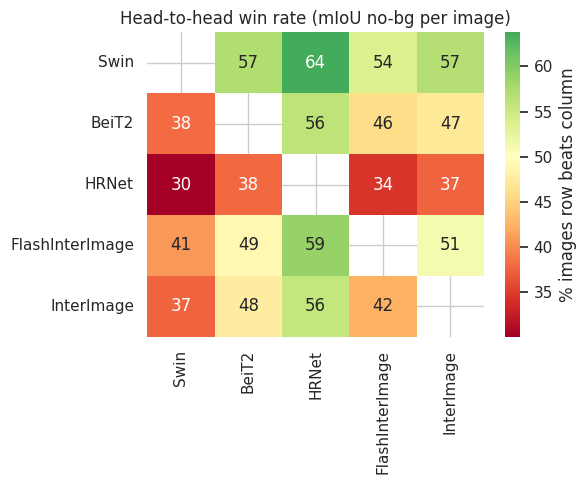


Detection hit-rate per model:
model
BeiT2              10.8
Swin               10.7
FlashInterImage     9.2
InterImage          8.6
HRNet               6.3


In [8]:
THRESH = 0.5
hit = piv >= THRESH
rows = []
for a, b in combinations(models, 2):
    d = piv[[a, b]].dropna()
    _, p_w = wilcoxon(d[a], d[b])
    wa, wb = int((d[a] > d[b]).sum()), int((d[b] > d[a]).sum())
    rbc = (wa - wb) / (wa + wb) if (wa + wb) else 0.0
    h = hit[[a, b]].dropna(); A, B = h[a].values, h[b].values
    b_, c_ = int((A & ~B).sum()), int((~A & B).sum()); nd = b_ + c_
    p_m = binomtest(min(b_, c_), nd, 0.5).pvalue if nd else 1.0
    rows.append({"A": a, "B": b, "n": len(d),
                 "median_d%": round((d[a]-d[b]).median()*100, 2),
                 "rank_biserial": round(rbc, 3), "p_wilcoxon": p_w,
                 "discordant": nd, "p_mcnemar": p_m})
res = pd.DataFrame(rows)
res["p_wilcoxon_holm"] = holm(res["p_wilcoxon"].values)
res["p_mcnemar_holm"] = holm(res["p_mcnemar"].values)
res["sig_W"] = np.where(res["p_wilcoxon_holm"] < 0.05, "*", "")
res["sig_M"] = np.where(res["p_mcnemar_holm"] < 0.05, "*", "")
print("Pairwise - Wilcoxon (mIoU/img) + McNemar (detection @0.5), Holm per test:")
display(res.sort_values("p_wilcoxon_holm").reset_index(drop=True))

win = pd.DataFrame(index=models, columns=models, dtype=float)
for a in models:
    for b in models:
        if a == b: win.loc[a, b] = np.nan; continue
        d = piv[[a, b]].dropna(); win.loc[a, b] = (d[a] > d[b]).mean()
plt.figure(figsize=(6, 5))
sns.heatmap(win.astype(float) * 100, annot=True, fmt=".0f", cmap="RdYlGn", center=50,
            cbar_kws={"label": "% images row beats column"})
plt.title("Head-to-head win rate (mIoU no-bg per image)"); plt.tight_layout(); plt.show()

print("\nDetection hit-rate per model:")
print((hit.mean().sort_values(ascending=False) * 100).round(1).to_string())

## 2. Depth / Distance

In [9]:
n = len(CLASS_NAMES)
zorder = ["near", "mid", "far"]
zone_rows = []
for mk in model_keys:
    for img_id in image_ids:
        gt, pred = load_aligned_masks(img_id, mk)
        if gt is None:
            continue
        h, w = gt.shape
        for zname, zmask in zone_masks(h, w):
            g, p = gt[zmask], pred[zmask]
            gt_c = np.bincount(g[g < n], minlength=n)
            pred_c = np.bincount(p[p < n], minlength=n)
            both = (g < n) & (p < n)
            inter = np.bincount(g[both & (g == p)], minlength=n)
            union = gt_c + pred_c - inter
            row = {"model": mk, "image_id": img_id, "zone": zname}
            ious_nobg = []
            for c in range(1, n):
                if union[c] > 0:
                    iou = inter[c] / union[c]
                    row[CLASS_NAMES[c]] = iou
                    ious_nobg.append(iou)
            row["mIoU_no_bg"] = np.mean(ious_nobg) if ious_nobg else np.nan
            zone_rows.append(row)
df_zone = pd.DataFrame(zone_rows)

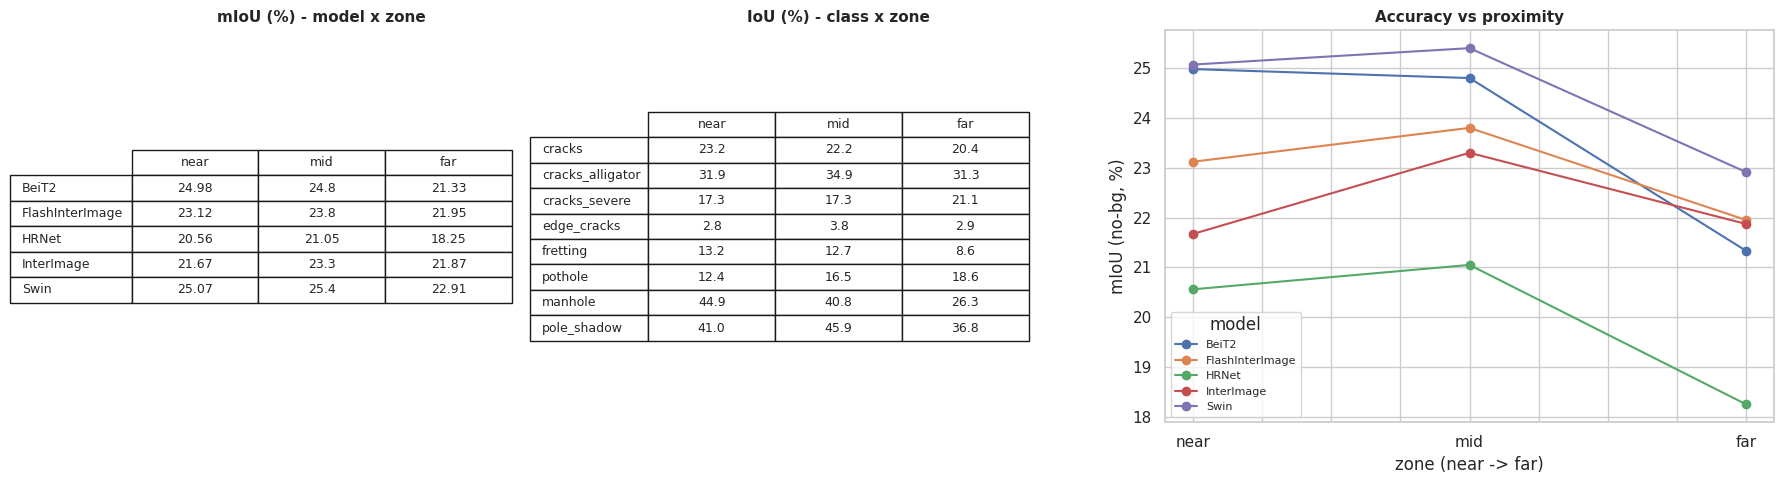

In [10]:
tbl = (df_zone.groupby(["model", "zone"])["mIoU_no_bg"].mean().unstack()[zorder] * 100).round(2)
present = [c for c in CLASS_NAMES[1:] if c in df_zone.columns]
per_class_zone = (df_zone.groupby("zone")[present].mean().reindex(zorder) * 100).round(1).T

fig, (a0, a1, a2) = plt.subplots(1, 3, figsize=(18, 5), gridspec_kw={"width_ratios": [1, 1, 1.6]})
def _table(ax, df, title):
    ax.axis("off"); ax.set_title(title, fontsize=11, fontweight="bold")
    t = ax.table(cellText=df.values, rowLabels=df.index, colLabels=df.columns, loc="center", cellLoc="center")
    t.auto_set_font_size(False); t.set_fontsize(9); t.scale(1, 1.5)
_table(a0, tbl, "mIoU (%) - model x zone")
_table(a1, per_class_zone, "IoU (%) - class x zone")
tbl.T.plot(marker="o", ax=a2)
a2.set_ylabel("mIoU (no-bg, %)"); a2.set_xlabel("zone (near -> far)")
a2.set_title("Accuracy vs proximity", fontsize=11, fontweight="bold")
a2.legend(title="model", fontsize=8)
plt.tight_layout(); plt.show()

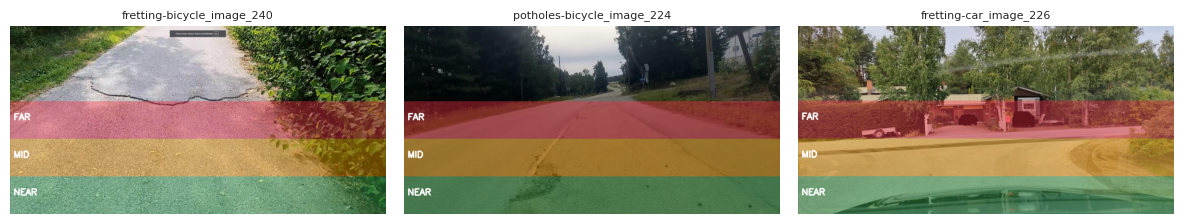

In [11]:
def zone_overlay(img_id, **kw):
    img = _load_original(img_id)
    if img is None:
        return None
    h, w = img.shape[:2]
    tint = {"near": (54, 179, 83), "mid": (255, 165, 0), "far": (250, 50, 69)}
    out = img.copy()
    for zname, zmask in zone_masks(h, w, **kw):
        out[zmask] = (0.6 * out[zmask] + 0.4 * np.array(tint[zname])).astype(np.uint8)
        y = int(np.where(zmask.any(1))[0].mean())
        cv2.putText(out, zname.upper(), (12, y), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 3)
    return out

def show_zones_grid(ids, ncols=3, **kw):
    ids = list(ids)
    nrows = math.ceil(len(ids) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    for ax, img_id in zip(np.array(axes).ravel(), ids):
        out = zone_overlay(img_id, **kw)
        if out is not None:
            ax.imshow(out); ax.set_title(img_id, fontsize=8)
        else:
            ax.text(0.5, 0.5, "not found", ha="center", va="center", color="crimson")
        ax.axis("off")
    for ax in np.array(axes).ravel()[len(ids):]:
        ax.axis("off")
    plt.tight_layout(); plt.show()

random.seed(0)
sample = random.sample(image_ids, 3)
show_zones_grid(sample)

In [12]:
N_BANDS, HORIZON_FRAC = 8, 0.40
def depth_bands(h, w, n=N_BANDS, horizon_frac=HORIZON_FRAC):
    cy = horizon_frac * h
    edges = np.linspace(cy, h, n + 1).astype(int)
    out = []
    for i in range(n):
        top, bot = edges[i], edges[i + 1]
        m = np.zeros((h, w), bool); m[top:bot, :] = True
        out.append((m, (1 - horizon_frac) / max((top + bot) / 2 / h - horizon_frac, 1e-6)))
    return out

n = len(CLASS_NAMES)
tp = collections.defaultdict(int); fp = collections.defaultdict(int); fn = collections.defaultdict(int)
correct = collections.defaultdict(int); total = collections.defaultdict(int); band_dist = {}
for mk in model_keys:
    for img_id in image_ids:
        gt, pred = load_aligned_masks(img_id, mk)
        if gt is None:
            continue
        for bi, (zmask, dist) in enumerate(depth_bands(*gt.shape)):
            band_dist[bi] = dist
            g, p = gt[zmask], pred[zmask]
            total[(mk, bi)] += int(g.size)
            gt_c = np.bincount(g[g < n], minlength=n)
            pred_c = np.bincount(p[p < n], minlength=n)
            both = (g < n) & (p < n)
            inter = np.bincount(g[both & (g == p)], minlength=n)
            correct[(mk, bi)] += int(inter.sum())
            for c in range(n):
                tp[(mk, bi, c)] += int(inter[c])
                fp[(mk, bi, c)] += int(pred_c[c] - inter[c])
                fn[(mk, bi, c)] += int(gt_c[c] - inter[c])

df_depth = pd.DataFrame([
    {"model": mk, "band": bi, "dist": round(band_dist[bi], 2), "class": CLASS_NAMES[c],
     "iou": tp[(mk,bi,c)] / d if (d := tp[(mk,bi,c)]+fp[(mk,bi,c)]+fn[(mk,bi,c)]) else np.nan,
     "recall": tp[(mk,bi,c)] / s if (s := tp[(mk,bi,c)]+fn[(mk,bi,c)]) else np.nan,
     "gt_px": tp[(mk,bi,c)] + fn[(mk,bi,c)]}
    for (mk, bi, c) in tp]).query("gt_px > 0")
df_acc = pd.DataFrame([{"model": mk, "band": bi, "dist": round(band_dist[bi], 2),
                        "aAcc": correct[(mk,bi)] / total[(mk,bi)]} for (mk, bi) in total])

/tmp/ipykernel_275/2588149820.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g = (df_depth.groupby(["model", "band", "dist"]).apply(lambda d: pd.Series({


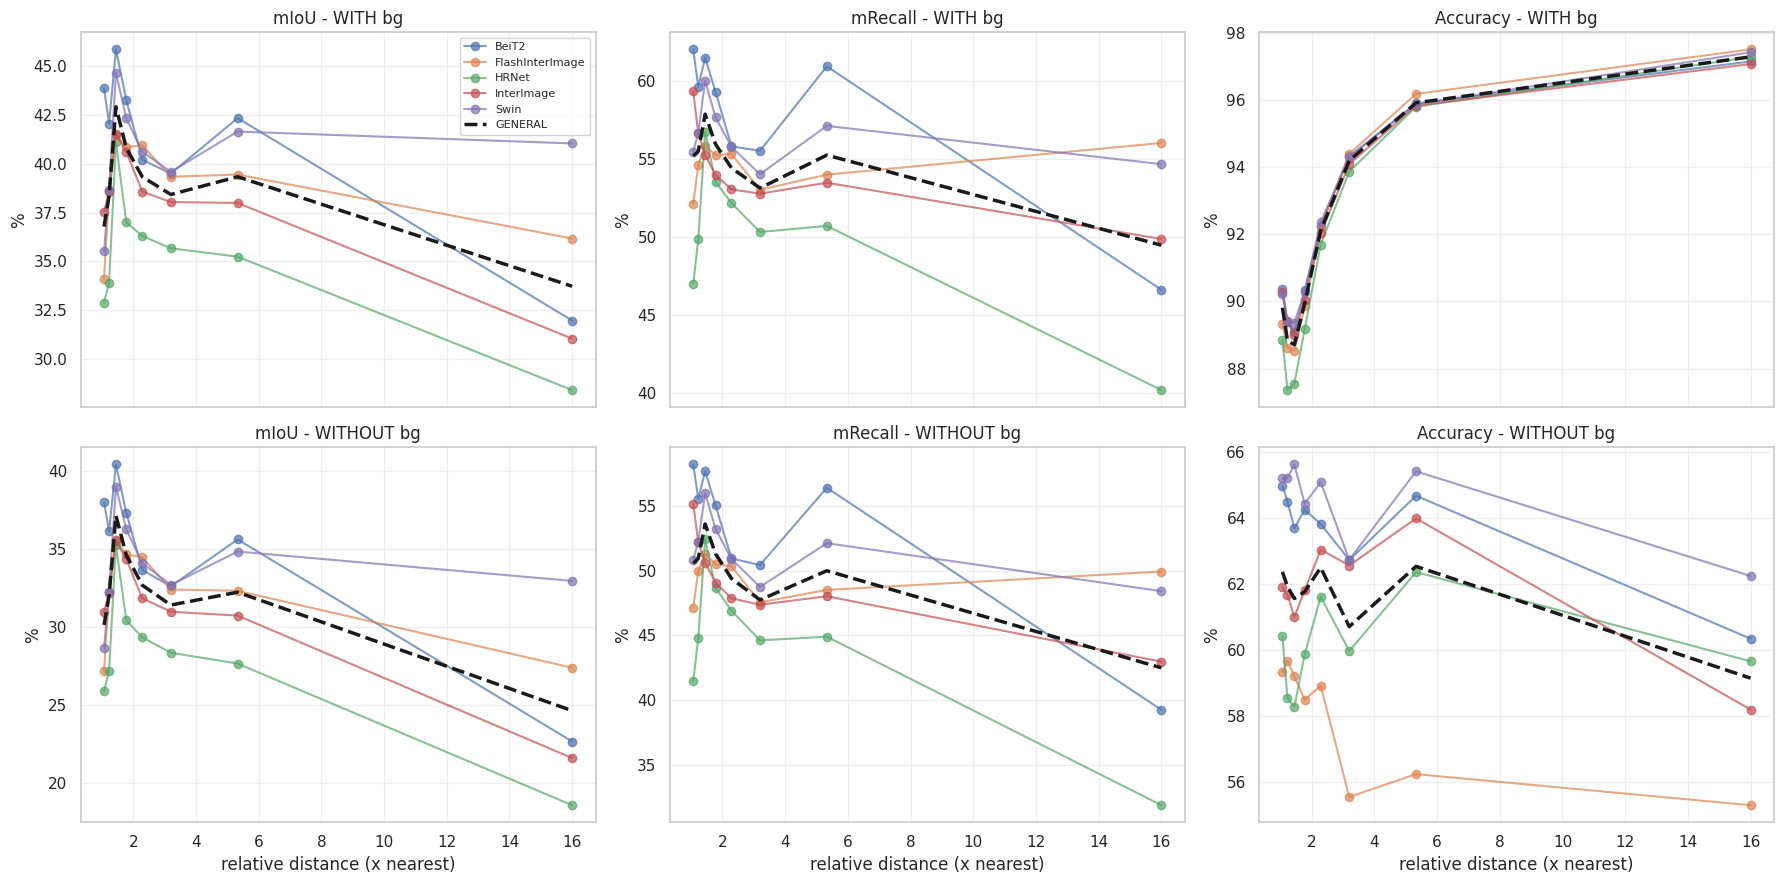

In [13]:
g = (df_depth.groupby(["model", "band", "dist"]).apply(lambda d: pd.Series({
    "mIoU_bg": d["iou"].mean(),
    "mIoU_nobg": d.loc[d["class"] != "bg", "iou"].mean(),
    "mRecall_bg": d["recall"].mean(),
    "mRecall_nobg": d.loc[d["class"] != "bg", "recall"].mean(),
})).reset_index())

acc_bg = pd.DataFrame([{"model": mk, "band": bi, "Acc_bg": correct[(mk,bi)] / total[(mk,bi)]}
                       for (mk, bi) in total])
fg = (df_depth[df_depth["class"] != "bg"].assign(_tp=lambda d: d.recall * d.gt_px)
      .groupby(["model", "band"]).agg(_tp=("_tp", "sum"), _gt=("gt_px", "sum")).reset_index())
fg["Acc_nobg"] = fg["_tp"] / fg["_gt"]
g = g.merge(acc_bg, on=["model", "band"]).merge(fg[["model", "band", "Acc_nobg"]], on=["model", "band"])

panels = [("WITH bg", ["mIoU_bg", "mRecall_bg", "Acc_bg"]),
          ("WITHOUT bg", ["mIoU_nobg", "mRecall_nobg", "Acc_nobg"])]
titles = ["mIoU", "mRecall", "Accuracy"]
fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True)
for r, (rowlab, cols) in enumerate(panels):
    for ccol, ax, t in zip(cols, axes[r], titles):
        for mk, sub in g.groupby("model"):
            sub = sub.sort_values("dist"); ax.plot(sub["dist"], sub[ccol] * 100, marker="o", alpha=0.7, label=mk)
        gen = g.groupby("dist")[ccol].mean().sort_index()
        ax.plot(gen.index, gen.values * 100, "k--", lw=2.5, label="GENERAL")
        ax.set_title(f"{t} - {rowlab}"); ax.set_ylabel("%"); ax.grid(alpha=0.3)
        if r == 1: ax.set_xlabel("relative distance (x nearest)")
axes[0, 0].legend(fontsize=8)
plt.tight_layout(); plt.show()

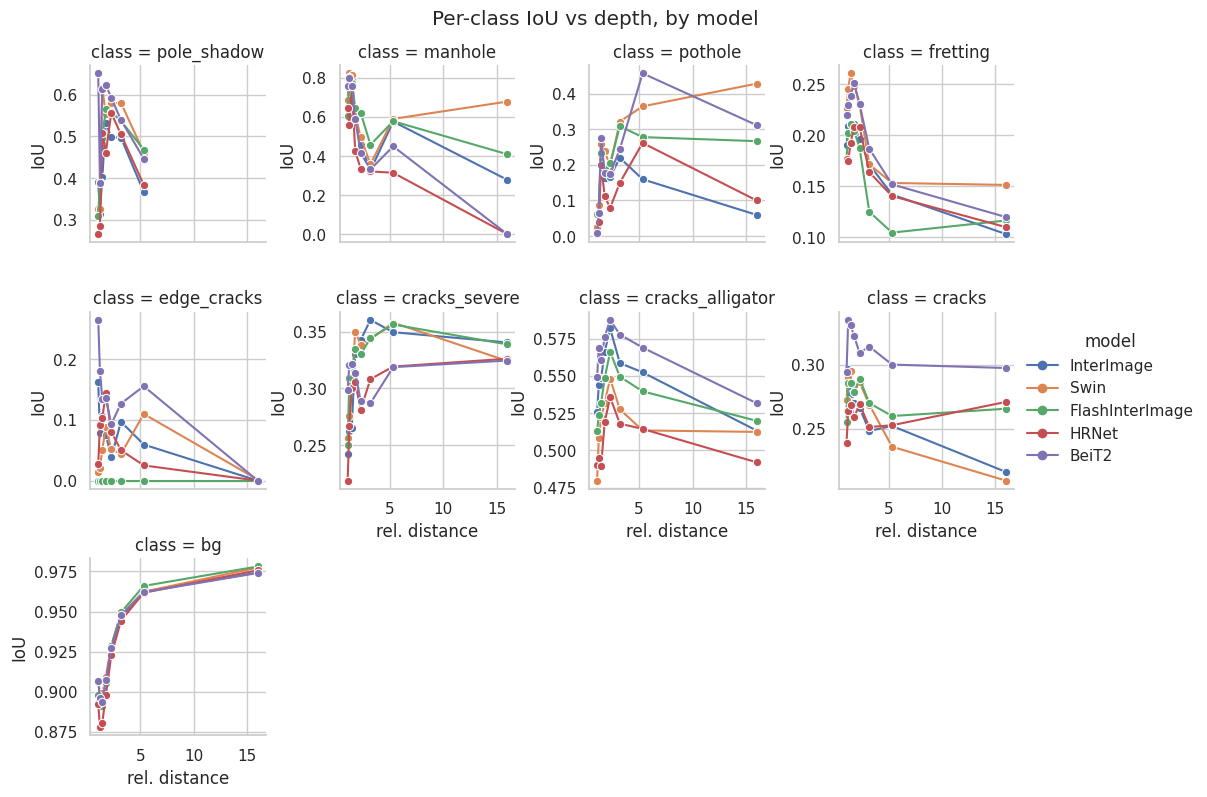

In [14]:
sub = df_depth[df_depth["gt_px"] >= 200]
gp = sns.relplot(data=sub.sort_values("dist"), x="dist", y="iou", hue="model",
                 col="class", col_wrap=4, kind="line", marker="o",
                 height=2.6, facet_kws={"sharey": False}, legend="full")
gp.set(xlabel="rel. distance", ylabel="IoU")
gp.figure.suptitle("Per-class IoU vs depth, by model", y=1.02)
plt.show()

## 3. Confusion, Size & Agreement

In [15]:
n = len(CLASS_NAMES)
crack_ids = [CLASS_NAMES.index(c) for c in ("cracks", "cracks_alligator", "cracks_severe")]
cm_total = np.zeros((n, n), np.int64)  # rows = GT, cols = Pred
size_rows, swap_rows = [], []
for mk in model_keys:
    for img_id in image_ids:
        gt, pred = load_aligned_masks(img_id, mk)
        if gt is None:
            continue
        cm = np.bincount(n * gt.ravel() + pred.ravel(), minlength=n*n).reshape(n, n)
        cm_total += cm
        sub = cm[np.ix_(crack_ids, crack_ids)]
        swap = int(sub.sum() - np.trace(sub))
        if swap:
            swap_rows.append({"image_id": img_id, "model": mk, "swap_px": swap})
        inter = np.diag(cm); gt_c = cm.sum(1); pred_c = cm.sum(0)
        union = gt_c + pred_c - inter
        for c in range(1, n):
            if gt_c[c]:
                size_rows.append({"image_id": img_id, "model": mk, "class": CLASS_NAMES[c],
                                  "gt_area_px": int(gt_c[c]), "iou": inter[c] / union[c]})
df_size = pd.DataFrame(size_rows)
df_swaps = pd.DataFrame(swap_rows).sort_values("swap_px", ascending=False)
print(f"Scanned {len(model_keys)} models x {len(image_ids)} images.")

Scanned 5 models x 724 images.


pixels per model: {'Swin': 600883200, 'BeiT2': 600883200, 'HRNet': 600883200, 'FlashInterImage': 600883200, 'InterImage': 600883200}


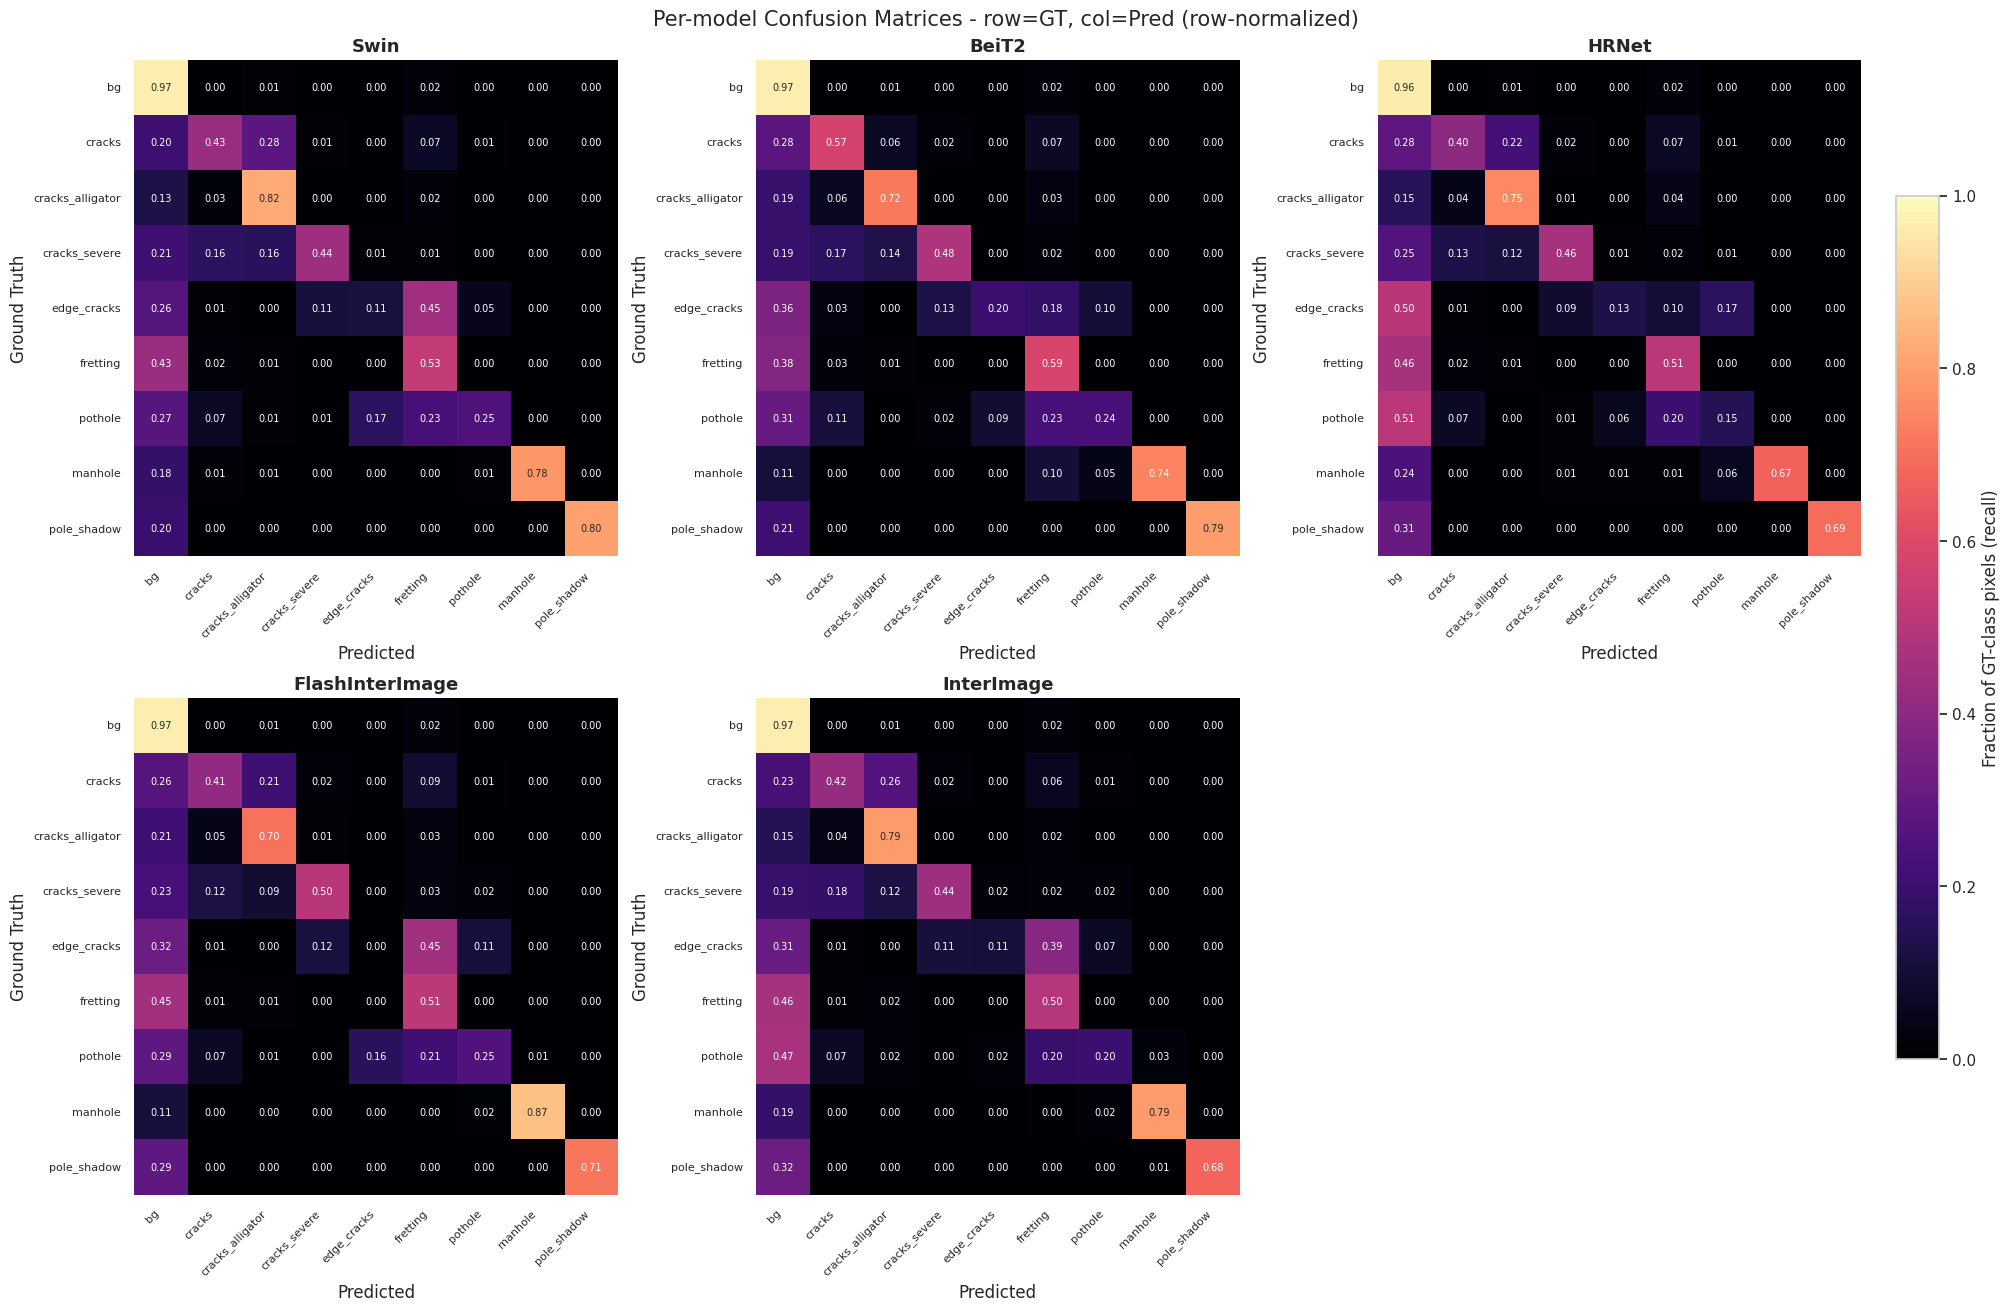

In [16]:
cm_by_model = {mk: np.zeros((n, n), np.int64) for mk in model_keys}
for mk in model_keys:
    for img_id in image_ids:
        gt, pred = load_aligned_masks(img_id, mk)
        if gt is None:
            continue
        cm_by_model[mk] += np.bincount(n * gt.ravel() + pred.ravel(), minlength=n*n).reshape(n, n)
print("pixels per model:", {mk: int(cm_by_model[mk].sum()) for mk in model_keys})

models = list(cm_by_model.keys())
fig, axes = plt.subplots(2, 3, figsize=(20, 13), constrained_layout=True)
axes = axes.ravel()
for ax, mk in zip(axes, models):
    cm = cm_by_model[mk].astype(float)
    cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_norm, ax=ax, annot=True, fmt='.2f', cmap='magma', vmin=0, vmax=1,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar=False, annot_kws={"size": 7})
    ax.set_title(mk, fontweight='bold', fontsize=13)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Ground Truth")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
for ax in axes[len(models):]:
    ax.axis('off')
sm = plt.cm.ScalarMappable(cmap='magma', norm=plt.Normalize(0, 1))
fig.colorbar(sm, ax=axes.tolist(), fraction=0.025, pad=0.02, label='Fraction of GT-class pixels (recall)')
fig.suptitle("Per-model Confusion Matrices - row=GT, col=Pred (row-normalized)", fontsize=15)
plt.show()

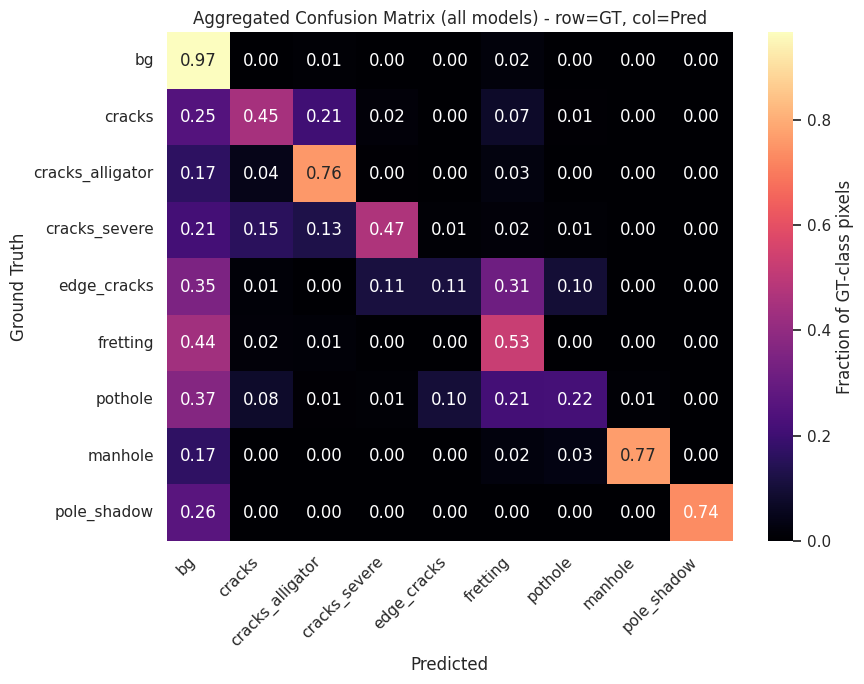

In [17]:
cm_norm = cm_total / cm_total.sum(axis=1, keepdims=True).clip(min=1)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='magma',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar_kws={'label': 'Fraction of GT-class pixels'})
plt.title("Aggregated Confusion Matrix (all models) - row=GT, col=Pred")
plt.xlabel("Predicted"); plt.ylabel("Ground Truth")
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

In [18]:
GROUPS = {
    "background": ["bg"],
    "crack": ["cracks", "cracks_alligator", "cracks_severe", "edge_cracks"],
    "fretting": ["fretting"], "pothole": ["pothole"],
    "manhole": ["manhole"], "pole_shadow": ["pole_shadow"],
}
defect_groups = [g for g in GROUPS if g != "background"]

def grouped_iou(cm, groups):
    out = {}
    for g, cs in groups.items():
        ii = [CLASS_NAMES.index(c) for c in cs]
        TP = cm[np.ix_(ii, ii)].sum(); FN = cm[ii, :].sum() - TP; FP = cm[:, ii].sum() - TP
        out[g] = TP / (TP + FP + FN) if (TP + FP + FN) else np.nan
    return pd.Series(out)

def fine_iou(cm):
    return pd.Series({CLASS_NAMES[i]: cm[i, i] / (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
                      for i in range(n)})

coarse_tbl = (pd.DataFrame({mk: grouped_iou(cm_by_model[mk], GROUPS) for mk in model_keys}).T * 100).round(1)
rows = []
for mk in model_keys:
    f, c = fine_iou(cm_by_model[mk]), grouped_iou(cm_by_model[mk], GROUPS)
    rows.append({"model": mk, "fine_mIoU": f[1:].mean() * 100, "coarse_mIoU": c[defect_groups].mean() * 100})
cmp = pd.DataFrame(rows).set_index("model").round(2)
cmp["d"] = (cmp["coarse_mIoU"] - cmp["fine_mIoU"]).round(2)
cmp = cmp.sort_values("coarse_mIoU", ascending=False)
detail = []
for mk in model_keys:
    f, c = fine_iou(cm_by_model[mk]), grouped_iou(cm_by_model[mk], GROUPS)
    detail.append({"model": mk, **{cs: round(f[cs] * 100, 1) for cs in GROUPS["crack"]},
                   "MERGED_crack": round(c["crack"] * 100, 1)})
detail_df = pd.DataFrame(detail).set_index("model")
side_by_side(coarse_tbl, cmp, detail_df,
             titles=["Coarse IoU (%) by group", "Fine vs coarse mIoU (no-bg)", "Crack subtypes vs merged (%)"])

Coarse IoU (%) by group 
 
 
 
   
 background 
 crack 
 fretting 
 pothole 
 manhole 
 pole_shadow 
 
 
 
 
 Swin 
 95.700000 
 54.500000 
 22.900000 
 20.700000 
 65.900000 
 52.400000 
 
 
 BeiT2 
 95.500000 
 54.900000 
 21.700000 
 18.500000 
 60.200000 
 57.000000 
 
 
 HRNet 
 95.100000 
 53.100000 
 18.200000 
 10.900000 
 51.500000 
 46.500000 
 
 
 FlashInterImage 
 95.500000 
 56.100000 
 18.200000 
 19.000000 
 66.200000 
 50.300000 
 
 
 InterImage 
 95.500000 
 57.400000 
 19.100000 
 14.600000 
 62.800000 
 44.700000 
 
 
 
 Fine vs coarse mIoU (no-bg) 
 
 
 
   
 fine_mIoU 
 coarse_mIoU 
 d 
 
 
 model 
   
   
   
 
 
 
 
 Swin 
 34.560000 
 43.270000 
 8.710000 
 
 
 BeiT2 
 36.160000 
 42.470000 
 6.310000 
 
 
 FlashInterImage 
 33.180000 
 41.950000 
 8.770000 
 
 
 InterImage 
 32.540000 
 39.720000 
 7.180000 
 
 
 HRNet 
 29.930000 
 36.030000 
 6.100000 
 
 
 
 Crack subtypes vs merged (%) 
 
 
 
   
 cracks 
 cracks_alligator 
 cracks_severe 
 edge_cracks 
 MERGED_crack 
 
 
 model 
   
   
   
   
   
 
 
 
 
 Swin 
 27.100000 
 51.400000 
 31.000000 
 5.100000 
 54.500000 
 
 
 BeiT2 
 31.300000 
 55.900000 
 30.600000 
 14.100000 
 54.900000 
 
 
 HRNet 
 25.700000 
 50.100000 
 28.200000 
 8.300000 
 53.100000 
 
 
 FlashInterImage 
 27.300000 
 53.200000 
 31.300000 
 0.000000 
 56.100000 
 
 
 InterImage 
 26.300000 
 54.600000 
 29.900000 
 8.300000 
 57.400000

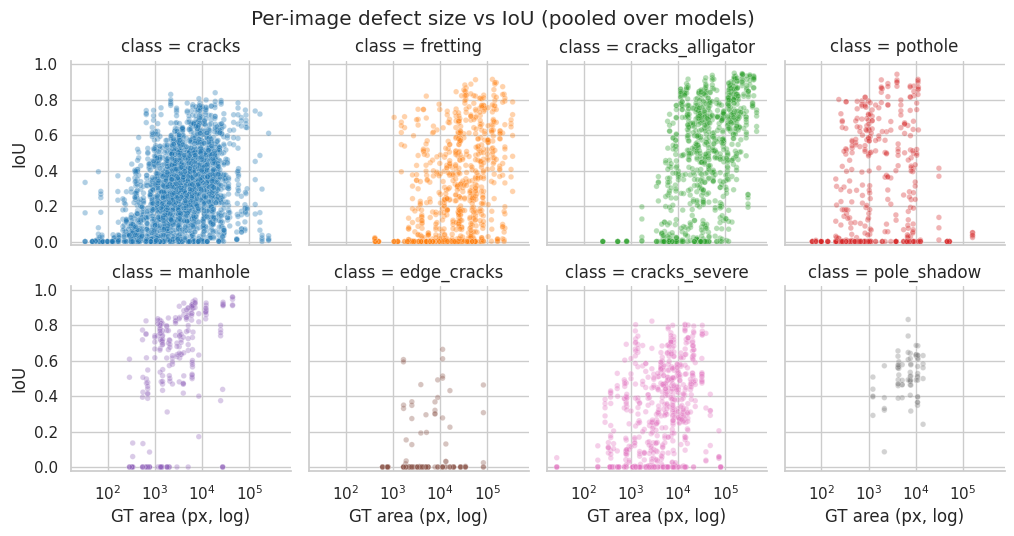

                       n  median_area_px  spearman_area_vs_iou
class                                                         
cracks            2705.0          3666.0                 0.370
cracks_alligator   880.0         37198.5                 0.492
cracks_severe      705.0          4591.0                 0.394
edge_cracks        155.0          3900.0                 0.187
fretting           825.0         24998.0                 0.412
manhole            250.0          2032.5                 0.567
pole_shadow         75.0          7594.0                 0.248
pothole            485.0           958.0                 0.336


/tmp/ipykernel_275/3693271867.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(df_size.groupby("class").apply(lambda d: pd.Series({


In [19]:
g = sns.relplot(data=df_size, x="gt_area_px", y="iou", col="class", hue="class",
                col_wrap=4, height=2.6, s=16, alpha=0.35, palette="tab10", legend=False)
g.set(xscale="log", ylim=(-0.02, 1.02))
g.set_axis_labels("GT area (px, log)", "IoU")
g.figure.suptitle("Per-image defect size vs IoU (pooled over models)", y=1.02)
plt.show()

print(df_size.groupby("class").apply(lambda d: pd.Series({
    "n": len(d), "median_area_px": d.gt_area_px.median(),
    "spearman_area_vs_iou": d.gt_area_px.corr(d.iou, method="spearman")
})).round(3))

In [20]:
# Headline per-class metrics, pooled over all models (from cm_total)
tp = np.diag(cm_total).astype(float)
fp = cm_total.sum(0) - tp
fn = cm_total.sum(1) - tp
with np.errstate(divide="ignore", invalid="ignore"):
    iou, prec, rec = tp/(tp+fp+fn), tp/(tp+fp), tp/(tp+fn)
    f1 = 2*prec*rec/(prec+rec)
results = (pd.DataFrame({"IoU": iou, "Precision": prec, "Recall": rec, "F1": f1},
                        index=CLASS_NAMES).loc[CLASS_NAMES[1:]] * 100)
results.loc["mean(no-bg)"] = results.mean()
display(results.round(1))

cm_prec = (cm_total / cm_total.sum(0, keepdims=True).clip(min=1) * 100)
side_by_side(pd.DataFrame((cm_total/cm_total.sum(1,keepdims=True).clip(min=1)*100).round(1),
                          index=CLASS_NAMES, columns=CLASS_NAMES).loc[CLASS_NAMES[1:]],
             pd.DataFrame(cm_prec.round(1), index=CLASS_NAMES, columns=CLASS_NAMES).loc[CLASS_NAMES[1:]],
             font_size=8, titles=["Recall view (row-norm %)", "Precision view (col-norm %)"])

Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


,bg,cracks,cracks_alligator,cracks_severe,edge_cracks,fretting,pothole,manhole,pole_shadow
cracks,25.100000,44.700000,20.600000,1.700000,0.100000,7.200000,0.600000,0.000000,0.000000
cracks_alligator,16.600000,4.400000,75.800000,0.500000,0.000000,2.800000,0.000000,0.000000,0.000000
cracks_severe,21.500000,15.500000,12.600000,46.700000,0.900000,1.800000,0.900000,0.100000,0.000000
edge_cracks,35.100000,1.500000,0.000000,11.100000,11.000000,31.500000,9.800000,0.000000,0.000000
fretting,43.700000,1.800000,1.400000,0.100000,0.000000,52.800000,0.200000,0.000000,0.000000
pothole,36.800000,7.700000,0.700000,0.800000,9.900000,21.400000,21.900000,0.800000,0.000000
manhole,16.700000,0.400000,0.200000,0.200000,0.200000,2.400000,3.000000,76.900000,0.100000
pole_shadow,26.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.200000,73.600000
,bg,cracks,cracks_alligator,cracks_severe,edge_cracks,fretting,pothole,manhole,pole_shadow
cracks,0.200000,42.000000,6.400000,7.200000,2.400000,2.100000,10.700000,0.500000,0.500000


## 4. Boundary / centerline / extent

In [21]:
TOL = 3
def _bnd(m):
    m = m.astype(np.uint8)
    return (m - cv2.erode(m, np.ones((3, 3), np.uint8))).astype(bool)

acc = collections.defaultdict(lambda: collections.defaultdict(float))
for img_id in image_ids:
    gt0 = next((g for mk in model_keys if (g := load_aligned_masks(img_id, mk)[0]) is not None), None)
    if gt0 is None:
        continue
    gt_side = {}
    for c in range(1, n):
        gt_c = gt0 == c
        if not gt_c.any():
            continue
        gb = _bnd(gt_c)
        dtg = cv2.distanceTransform((~gb).astype(np.uint8), cv2.DIST_L2, 3)
        sk = skeletonize(gt_c)
        gt_side[c] = (gt_c, gb, dtg, sk)
    for mk in model_keys:
        gt, pred = load_aligned_masks(img_id, mk)
        if gt is None:
            continue
        for c, (gt_c, gb, dtg, sk) in gt_side.items():
            pred_c = pred == c
            k = (mk, CLASS_NAMES[c])
            acc[k]["tp"] += int((gt_c & pred_c).sum())
            acc[k]["fp"] += int((pred_c & ~gt_c).sum())
            acc[k]["fn"] += int((gt_c & ~pred_c).sum())
            pb = _bnd(pred_c)
            acc[k]["gb"] += gb.sum(); acc[k]["pb"] += pb.sum()
            if pb.any():
                acc[k]["pb_hit"] += int((dtg[pb] <= TOL).sum())
            if gb.any():
                dtp = cv2.distanceTransform((~pb).astype(np.uint8), cv2.DIST_L2, 3)
                acc[k]["gb_hit"] += int((dtp[gb] <= TOL).sum())
            if sk.any():
                dt = cv2.distanceTransform((~pred_c).astype(np.uint8), cv2.DIST_L2, 3)
                acc[k]["skel"] += int(sk.sum())
                acc[k]["skel_hit"] += int((dt[sk] <= TOL).sum())
print(f"Done (tol={TOL}px).")

Done (tol=3px).


Per-class (mean over models). Big gap = found but penalized by thinness:


Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


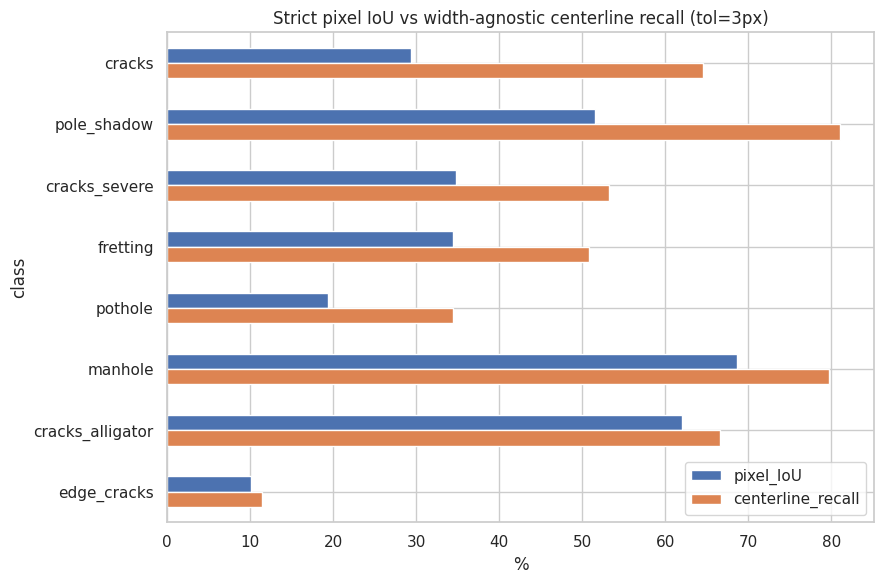


Per-model centerline-IoU gap (%):


Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


In [22]:
rows = []
for (mk, cls), a in acc.items():
    den = a["tp"] + a["fp"] + a["fn"]
    bp = a["pb_hit"] / a["pb"] if a["pb"] else np.nan
    br = a["gb_hit"] / a["gb"] if a["gb"] else np.nan
    rows.append({"model": mk, "class": cls,
                 "pixel_IoU": a["tp"] / den if den else np.nan,
                 "boundary_F": 2*bp*br/(bp+br) if (bp and br) else 0.0,
                 "centerline_recall": a["skel_hit"] / a["skel"] if a["skel"] else np.nan})
df_bnd = pd.DataFrame(rows)
per_class = (df_bnd.groupby("class")[["pixel_IoU", "boundary_F", "centerline_recall"]].mean() * 100).round(1)
per_class["centerline-IoU_gap"] = (per_class["centerline_recall"] - per_class["pixel_IoU"]).round(1)
per_class = per_class.sort_values("centerline-IoU_gap", ascending=False)
print("Per-class (mean over models). Big gap = found but penalized by thinness:")
display(per_class)

ax = per_class[["pixel_IoU", "centerline_recall"]].plot.barh(figsize=(9, 6))
plt.xlabel("%"); plt.gca().invert_yaxis()
plt.title(f"Strict pixel IoU vs width-agnostic centerline recall (tol={TOL}px)")
plt.tight_layout(); plt.show()

gap = df_bnd.assign(gap=(df_bnd.centerline_recall - df_bnd.pixel_IoU) * 100)
print("\nPer-model centerline-IoU gap (%):")
display(gap.pivot_table(index="model", columns="class", values="gap").round(1))

## 5. Error Composition - False Positives & Wrong Detections

In [23]:
defect_gt_px = int(cm_total[1:, :].sum())
omit_px = int(cm_total[1:, 0].sum())
fp_px = int(cm_total[0, 1:].sum())
print(f"Omission (GT defect -> bg): {omit_px/defect_gt_px:.1%} of defect pixels")
print(f"False positives (bg -> defect): {fp_px:,} px total")
print(f"FP / GT-defect-px ratio: {fp_px/defect_gt_px:.2f}")

Omission (GT defect -> bg): 26.3% of defect pixels
False positives (bg -> defect): 95,188,968 px total
FP / GT-defect-px ratio: 0.68


In [24]:
cm_pct = (cm_total / cm_total.sum(1, keepdims=True).clip(min=1) * 100).round(1)
dest_pooled = pd.DataFrame(cm_pct, index=CLASS_NAMES, columns=CLASS_NAMES).loc[CLASS_NAMES[1:]]
print("GT-class destination (%) - row=GT, col=Pred (diagonal=correct, 'bg' col=omission):")
display(dest_pooled)

GT-class destination (%) - row=GT, col=Pred (diagonal=correct, 'bg' col=omission):


Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


## 6. Majority vote & Best Model

In [25]:
def majority_vote(preds, prefer_defect=False):
    P = np.stack(preds)
    counts = np.stack([(P == c).sum(0) for c in range(n)])
    if prefer_defect:
        ens = np.where(counts[1:].max(0) >= counts[0], counts[1:].argmax(0) + 1, 0)
    else:
        ens = counts.argmax(0)
    return ens.astype(np.uint8)

tp = collections.defaultdict(int); fp = collections.defaultdict(int); fn = collections.defaultdict(int)
ens_rows = []
for img_id in image_ids:
    gt, preds = None, []
    for mk in model_keys:
        g, p = load_aligned_masks(img_id, mk)
        if g is None:
            preds = None; break
        gt = g; preds.append(p)
    if not preds:
        continue
    members = {mk: preds[i] for i, mk in enumerate(model_keys)}
    members["Ensemble"] = majority_vote(preds)
    gf = gt.ravel()
    for name, pr in members.items():
        cm = np.bincount(n * gf + pr.ravel(), minlength=n*n).reshape(n, n)
        diag = np.diag(cm); rowsum = cm.sum(1); colsum = cm.sum(0)
        for c in range(n):
            tp[(name, c)] += int(diag[c]); fp[(name, c)] += int(colsum[c] - diag[c]); fn[(name, c)] += int(rowsum[c] - diag[c])
    ens = members["Ensemble"]; ib, inb = [], []
    for c in range(n):
        u = np.logical_or(gt == c, ens == c).sum()
        if u:
            i = np.logical_and(gt == c, ens == c).sum() / u
            ib.append(i); (inb.append(i) if c else None)
    ens_rows.append({"image_id": img_id, "model": "Ensemble",
                     "mIoU_with_bg": np.mean(ib) if ib else np.nan,
                     "mIoU_without_bg": np.mean(inb) if inb else np.nan})
df_ens = pd.DataFrame(ens_rows)
print(f"Ensembled {len(df_ens)} images.")

Ensembled 724 images.


In [26]:
single = df_compare.groupby("model")["mIoU_without_bg"].mean() * 100
tbl = single.copy(); tbl["Ensemble"] = df_ens["mIoU_without_bg"].mean() * 100
print("Per-image mIoU (no-bg), macro:")
print(tbl.sort_values(ascending=False).round(2).to_string())

best = single.idxmax()
b = df_compare[df_compare.model == best].set_index("image_id")["mIoU_without_bg"]
e = df_ens.set_index("image_id")["mIoU_without_bg"]
d = pd.concat([b.rename("best"), e.rename("ens")], axis=1).dropna()
stat, p = wilcoxon(d.ens, d.best)
print(f"\nEnsemble vs best single ({best}): median d = {(d.ens - d.best).median()*100:+.2f} pp | "
      f"ensemble wins {int((d.ens > d.best).sum())}/{len(d)} images | p = {p:.2e}")

iou = lambda nm, c: (tp[(nm,c)] / s if (s := tp[(nm,c)] + fp[(nm,c)] + fn[(nm,c)]) else np.nan)
names = model_keys + ["Ensemble"]
pc = pd.DataFrame({nm: [iou(nm, c) for c in range(1, n)] for nm in names}, index=CLASS_NAMES[1:]) * 100
print("\nPooled per-class IoU (%) - models vs Ensemble:")
display(pc.round(1))

Per-image mIoU (no-bg), macro:
model
Ensemble           26.16
Swin               25.58
BeiT2              24.65
FlashInterImage    23.94
InterImage         22.96
HRNet              20.32

Ensemble vs best single (Swin): median d = +0.19 pp | ensemble wins 363/693 images | p = 2.82e-02

Pooled per-class IoU (%) - models vs Ensemble:


Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


In [27]:
def pooled_pc(mk):
    cm = cm_by_model[mk].astype(float)
    inter = np.diag(cm); union = cm.sum(1) + cm.sum(0) - inter
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(union > 0, 100 * inter / union, np.nan)

perimg = df_compare.groupby("model")[["mIoU_with_bg", "mIoU_without_bg"]].mean() * 100
summary = pd.DataFrame({
    "pooled_wbg": {m: np.nanmean(pooled_pc(m)) for m in model_keys},
    "pooled_nobg": {m: np.nanmean(pooled_pc(m)[1:]) for m in model_keys},
    "perimg_wbg": perimg["mIoU_with_bg"],
    "perimg_nobg": perimg["mIoU_without_bg"],
}).round(2)
print(summary)
pc_tbl = pd.DataFrame({m: pooled_pc(m) for m in model_keys}, index=CLASS_NAMES).round(1)
print(pc_tbl)

                 pooled_wbg  pooled_nobg  perimg_wbg  perimg_nobg
BeiT2                 42.75        36.16       49.06        24.65
FlashInterImage       40.10        33.18       47.23        23.94
HRNet                 37.17        29.93       43.83        20.32
InterImage            39.53        32.54       45.84        22.96
Swin                  41.35        34.56       48.31        25.58
                  Swin  BeiT2  HRNet  FlashInterImage  InterImage
bg                95.7   95.5   95.1             95.5        95.5
cracks            27.1   31.3   25.7             27.3        26.3
cracks_alligator  51.4   55.9   50.1             53.2        54.6
cracks_severe     31.0   30.6   28.2             31.3        29.9
edge_cracks        5.1   14.1    8.3              0.0         8.3
fretting          22.9   21.7   18.2             18.2        19.1
pothole           20.7   18.5   10.9             19.0        14.6
manhole           65.9   60.2   51.5             66.2        62.8
pole_shado

## 7. FP on Clean Images

In [28]:
clean_images_to_analyze = df_clean['image_id'].unique()
fp_records = []
for model_key in model_keys:
    for img_id in clean_images_to_analyze:
        _, pred_mask = load_aligned_masks(img_id, model_key)
        if pred_mask is None:
            continue
        pixel_counts = np.bincount(pred_mask.ravel(), minlength=len(CLASS_NAMES))
        img_fp_data = {"image_id": img_id, "model": model_key}
        for c_idx, c_name in enumerate(CLASS_NAMES[1:], start=1):
            count = int(pixel_counts[c_idx])
            img_fp_data[f"fp_pixels_{c_name}"] = count
            img_fp_data[f"fp_detected_{c_name}"] = 1 if count > 0 else 0
        total_fp_pixels = int(np.sum(pixel_counts[1:]))
        img_fp_data["total_fp_pixels"] = total_fp_pixels
        img_fp_data["has_any_false_positive"] = 1 if total_fp_pixels > 0 else 0
        fp_records.append(img_fp_data)
df_fp_analysis = pd.DataFrame(fp_records)

print(" Total Clean Images Falsely Flagged (fewer is better):")
print(df_fp_analysis.groupby('model')['has_any_false_positive'].sum().sort_values().to_string())

detected_cols = [c for c in df_fp_analysis.columns if 'fp_detected_' in c]
df_class_distribution = df_fp_analysis.groupby('model')[detected_cols].sum()
df_class_distribution.columns = [c.replace('fp_detected_', '') for c in df_class_distribution.columns]
pixel_cols = [c for c in df_fp_analysis.columns if 'fp_pixels_' in c]
df_pixel_severity = df_fp_analysis.groupby('model')[pixel_cols].mean().round(1)
df_pixel_severity.columns = [c.replace('fp_pixels_', '') for c in df_pixel_severity.columns]
side_by_side(df_class_distribution, df_pixel_severity, font_size=9,
             titles=["FP incidence - clean images flagged, per class", "FP severity - mean FP pixels, per class"])
print("\n Defect classes ranked by total FP incidents across ALL models:")
print(df_class_distribution.sum().sort_values(ascending=False).to_string())

 Total Clean Images Falsely Flagged (fewer is better):
model
BeiT2              26
FlashInterImage    29
HRNet              35
InterImage         37
Swin               37


,cracks,cracks_alligator,cracks_severe,edge_cracks,fretting,pothole,manhole,pole_shadow
model,,,,,,,,
BeiT2,18,2,3,0,6,1,5,0
FlashInterImage,20,2,1,0,11,3,2,1
HRNet,21,3,3,3,17,2,4,1
InterImage,29,3,2,4,15,0,4,0
Swin,31,1,1,3,9,1,4,1
,cracks,cracks_alligator,cracks_severe,edge_cracks,fretting,pothole,manhole,pole_shadow
model,,,,,,,,
BeiT2,415.700000,4988.200000,27.500000,0.000000,4475.100000,10.600000,175.300000,0.000000
FlashInterImage,459.200000,3913.800000,15.100000,0.000000,9403.600000,24.500000,136.200000,2.200000



 Defect classes ranked by total FP incidents across ALL models:
cracks              119
fretting             58
manhole              19
cracks_alligator     11
cracks_severe        10
edge_cracks          10
pothole               7
pole_shadow           3


## 8. Qualitative side by side & final panel

 Case: 0eb18616-d3aa-4c89-a38c-b08d15710fc9-01526_orig


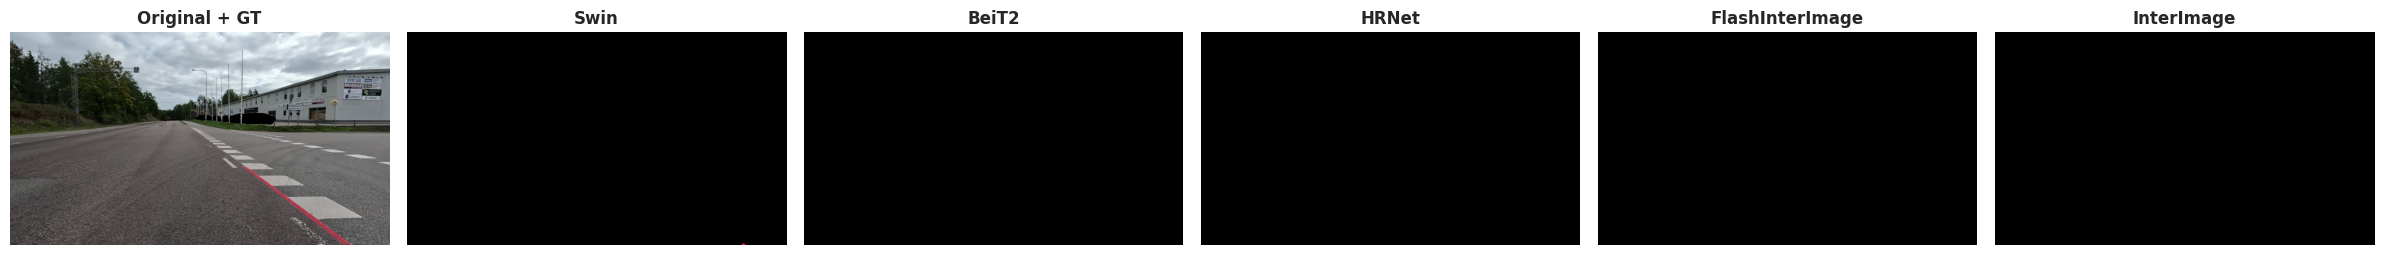

 Case: potholes-bicycle_image_359


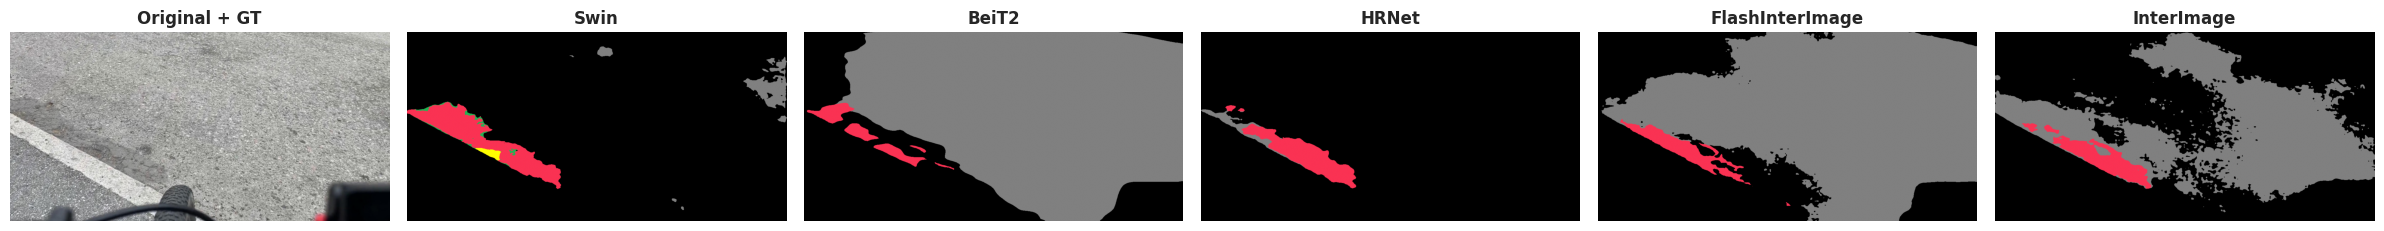

 Case: transverse-cracks-car_image_262


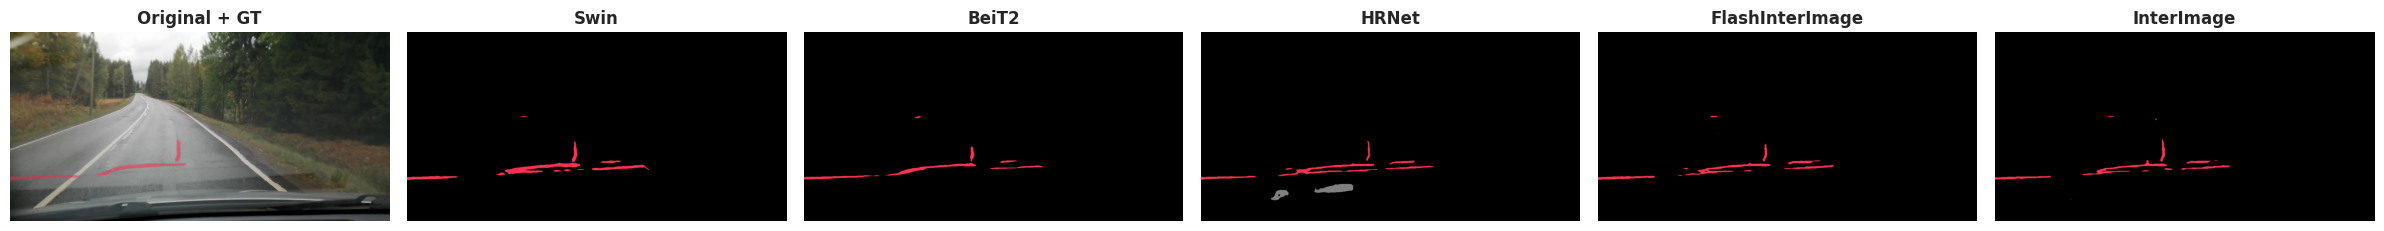

 Case: fretting-car_image_420


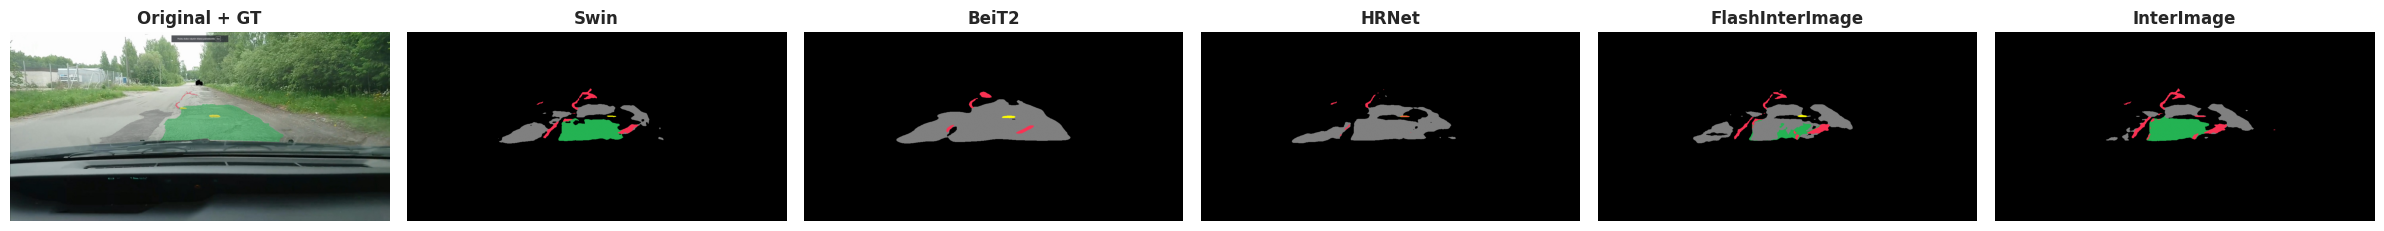

 Case: alligator-cracks-bicycle_image_77


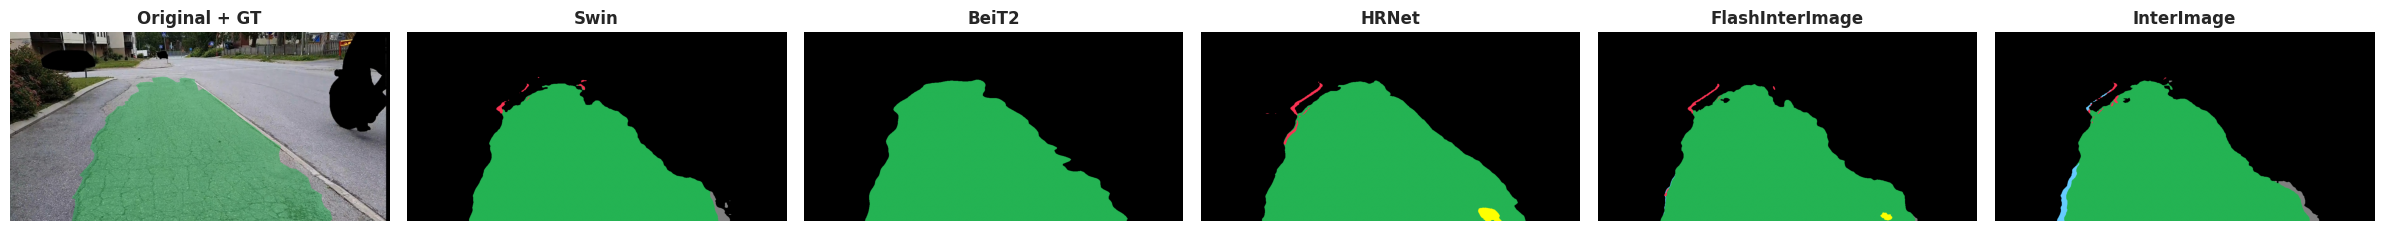

 Case: 48f4eef1-ac06-4693-8627-d3cbf04eaebf-04716_orig


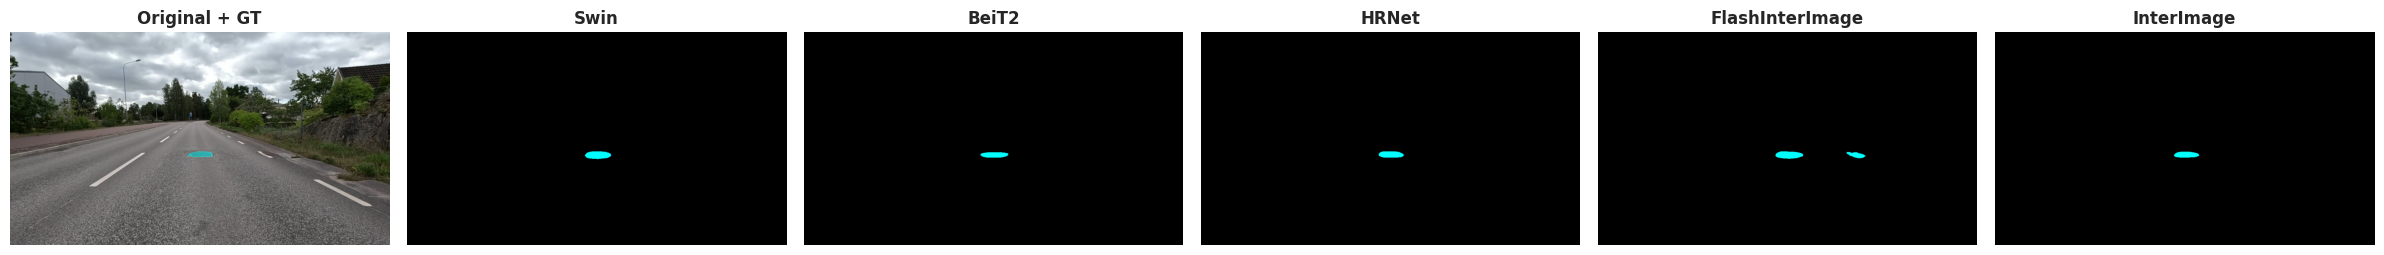

 Case: longitudinal-cracks-car_image_316


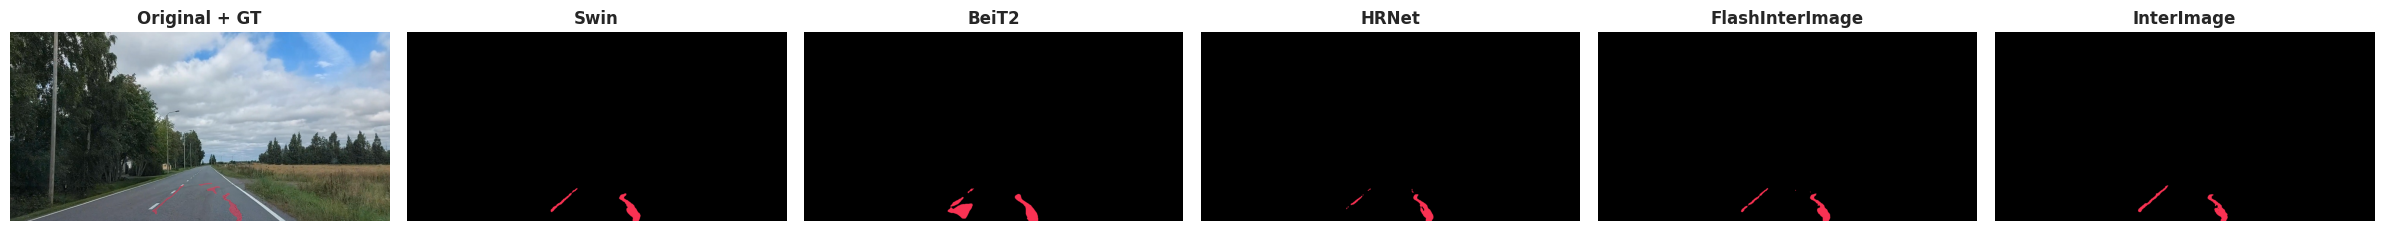

 Case: 0eb18616-d3aa-4c89-a38c-b08d15710fc9-01413_orig


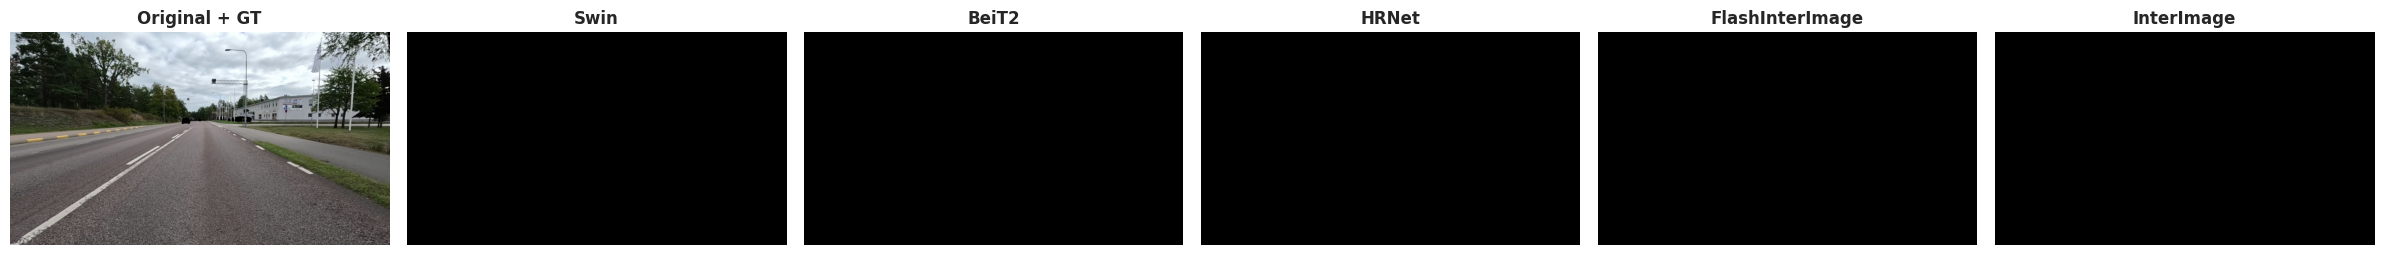

In [29]:
gallery = image_ids if RUN_HEAVY_VISUALS else image_ids[:N_SHOW]
for img_id in gallery:
    print(f" Case: {img_id}")
    show_all_models(img_id)

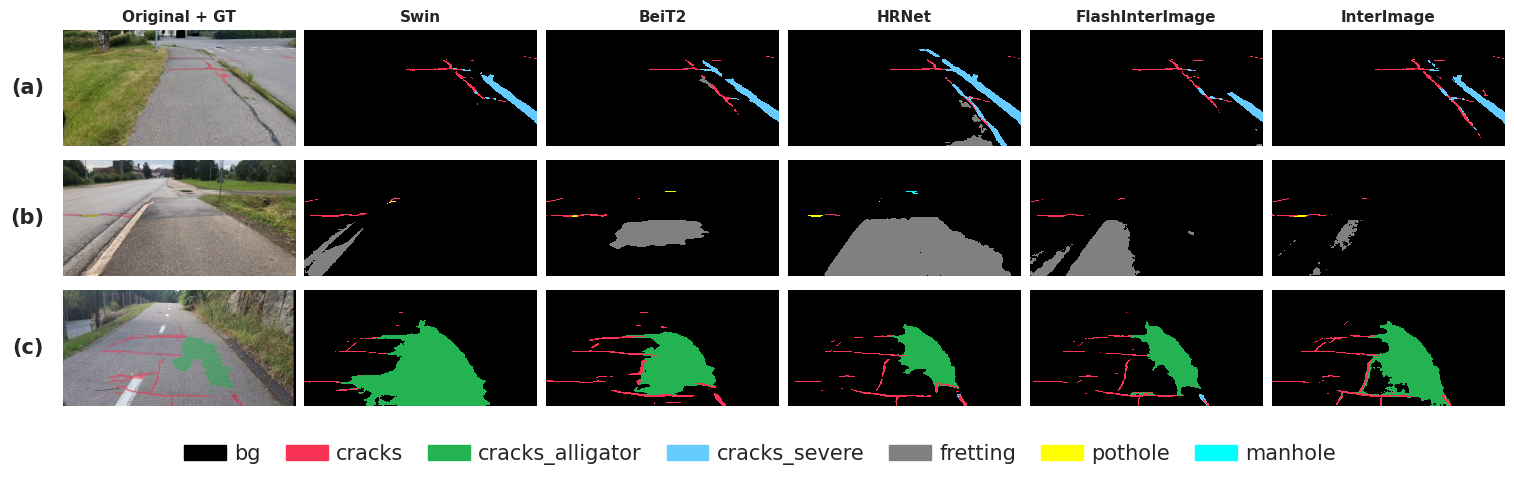

saved figures/qualitative_panel_i1.png


In [31]:
# ===== PANEL I1 - 3 cases x (Original+GT + 5 models) =====
ROWS = [
    "longitudinal-cracks-bicycle_image_184",     # (a) detected but penalised
    "potholes-bicycle_image_77",                # (b) detected but misclassified
    "alligator-cracks-bicycle_image_494",       # (c) models disagree
]
COLS = ["Original + GT"] + model_keys
present = set()
for img_id in ROWS:
    g = cv2.imread(str(PATHS["Ground_Truth"] / f"{img_id}.png"), cv2.IMREAD_GRAYSCALE)
    if g is not None:
        present |= set(np.unique(g))
    for mk in model_keys:
        _, p = load_aligned_masks(img_id, mk)
        if p is not None:
            present |= set(np.unique(p))
present = sorted(i for i in present if i < len(CLASS_NAMES))
legend_handles = [mpatches.Patch(color=np.array(PALETTE[i]) / 255, label=CLASS_NAMES[i]) for i in present]

nrows, ncols = len(ROWS), len(COLS)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.1 * ncols, 3.0 * nrows))
if nrows == 1:
    axes = axes[None, :]
for r, img_id in enumerate(ROWS):
    ov = overlay_gt(img_id)
    if ov is not None:
        axes[r, 0].imshow(ov)
    else:
        axes[r, 0].text(0.5, 0.5, "Not Found", ha="center", va="center", color="crimson")
    for c, mk in enumerate(model_keys, start=1):
        _, pred = load_aligned_masks(img_id, mk)
        if pred is not None:
            axes[r, c].imshow(pred, cmap=CMAP, norm=NORM, interpolation="nearest")
        else:
            axes[r, c].text(0.5, 0.5, "Not Found", ha="center", va="center", color="crimson")
    if r == 0:
        for c, name in enumerate(COLS):
            axes[r, c].set_title(name, fontsize=11, fontweight="bold")
    axes[r, 0].text(-0.08, 0.5, f"({chr(97 + r)})", transform=axes[r, 0].transAxes,
                    fontsize=15, fontweight="bold", va="center", ha="right")
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)
plt.subplots_adjust(hspace=-0.7, wspace=0.04)
fig.legend(handles=legend_handles, loc="lower center", ncol=len(legend_handles), frameon=False,
           fontsize=15, handletextpad=0.4, columnspacing=1.2, bbox_to_anchor=(0.5, 0.2))
Path("figures").mkdir(exist_ok=True)
fig.savefig("figures/qualitative_panel_i1.png", dpi=200, bbox_inches="tight")
plt.show()
print("saved figures/qualitative_panel_i1.png")